(16,)


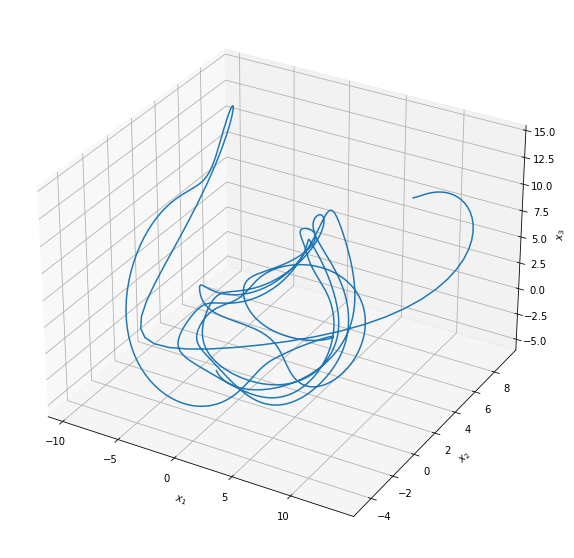

In [67]:
from scipy.integrate import odeint
import matplotlib.pyplot as plt
import numpy as np

# These are our constants
N = 16  # Number of variables
F = 8  # Forcing

sigma_e = 1e-6

def L96(x, t):
    """Lorenz 96 model with constant forcing"""
    # Setting up vector
    d = np.zeros(N)
    # Loops over indices (with operations and Python underflow indexing handling edge cases)
    for i in range(N):
        d[i] = (x[(i + 1) % N] - x[i - 2]) * x[i - 1] - x[i] + F + np.random.randn(1,1) * sigma_e
    return d


#x0 = F * np.ones(N)  # Initial state (equilibrium)
#x0[0] += 0.01  # Add small perturbation to the first variable
x0 = F + np.random.randn(N,)
print(x0.shape)
t = np.arange(0.0, 10.0, 0.01)

x = odeint(L96, x0, t)

# Plot the first three variables
fig = plt.figure(figsize=(14,10))
ax = fig.add_subplot(projection="3d")
ax.plot(x[:, 13], x[:, 14], x[:, 15])
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_zlabel("$x_3$")
plt.show()